# Failure Diagnosis and Continuation Redesign

## Crypto Alpha Across Horizons

The prior notebook ended with a frozen **2023–2024 validation failure**. This notebook starts only after that failure.

Its job is to show how the research was redesigned **without touching 2025+**:

1. diagnose the original failure on a true Binance-native 1h source clock;
2. separate elapsed formation/holding horizons from decision cadence;
3. test reversal and continuation independently under chronological pre-2025 replay;
4. reject reversal as statistically persistent but economically non-tradable;
5. extend continuation only where the pre-2025 evidence justified an extension;
6. map a broad formation × holding × cadence surface rather than optimize one cell;
7. freeze three exact continuation archetypes **before** the final 2025+ holdout is opened.

### Public-package execution design

The original diagnostic/replay notebooks produced large pre-2025 research caches after thousands of portfolio evaluations. This public notebook deliberately **does not rerun those expensive grids by default**. Instead it:

- reloads the frozen pre-2025 result tables produced by the canonical engines;
- recomputes the decisive summaries from those tables;
- applies integrity checks and exact finalist regression checks;
- keeps the final-test firewall explicit.

The reusable heavy-grid engines are appropriate for the repository's shared research code rather than being duplicated inside the public research notebook.

In [1]:
from pathlib import Path
from collections import OrderedDict
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def locate_project_root():
    env_root = os.getenv("CRYPTO_ALPHA_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / "data").is_dir():
            return candidate

    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd.parent,
        cwd / "crypto-alpha-research",
        cwd.parent / "crypto-alpha-research",
    ]
    for candidate in candidates:
        if (candidate / "data").is_dir() and (
            (candidate / "notebooks").is_dir()
            or (candidate / "public_notebooks").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root. Set CRYPTO_ALPHA_ROOT "
        "to the crypto-alpha-research folder."
    )


PROJECT_ROOT = locate_project_root()
RESEARCH_DIR = PROJECT_ROOT / "data" / "research"
PROCESSED_1H_DIR = PROJECT_ROOT / "data" / "processed_1h"
UNIVERSE_DIR = PROJECT_ROOT / "data" / "universe"

FINAL_TEST_START = pd.Timestamp("2025-01-01 00:00:00", tz="UTC")

print("Project root:", PROJECT_ROOT)
print("Research cache:", RESEARCH_DIR)
print("Final-test firewall:", FINAL_TEST_START)

Project root: /Users/owensimon/crypto-alpha-research
Research cache: /Users/owensimon/crypto-alpha-research/data/research
Final-test firewall: 2025-01-01 00:00:00+00:00


## 1. What failed, and what was reopened

The original Cycle-A momentum specification was a **3-day formation → 1-week forward** relationship sampled on the 4h decision clock. It looked positive in 2020–2022 but failed frozen 2023–2024 validation.

The post-validation diagnosis did **not** open the final test. It changed the research clock to true native 1h bars through 2024 only and asked a narrower question:

> Was the failure specific to the old specification, or did the cross-sectional return structure contain a different, more stable horizon architecture?

Three implementation dimensions were separated:

- **formation horizon:** how far back the signal looks;
- **holding horizon:** how long a signal vintage remains active;
- **decision cadence:** how often the portfolio may refresh.

The 1h diagnostic stage first reproduced the old 4h surface closely, then expanded the horizon/cadence map. The old 3d → 1w momentum relationship changed sign in 2023–2024 across cadences, while very-short reversal remained negative and a different short-formation continuation region appeared more stable.

Market-trend, volatility, dispersion, and abnormal-activity state diagnostics were also explored at this stage. They did not justify a robust state-dependent trading filter, so no market-state rule was promoted into the final architecture.

In [3]:
required_step10 = {
    "reproduction": RESEARCH_DIR / "step10_step3_reproduction_check.csv",
    "frequency": RESEARCH_DIR / "step10_frequency_surface_stats.csv",
    "yearly": RESEARCH_DIR / "step10_key_candidate_yearly_ic.csv",
    "shortlist": RESEARCH_DIR / "step10_diagnostic_horizon_shortlist.csv",
}

for label, path in required_step10.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing Step-10 frozen result: {path}")

step10_reproduction = pd.read_csv(required_step10["reproduction"])
step10_frequency = pd.read_csv(required_step10["frequency"])
step10_yearly = pd.read_csv(required_step10["yearly"])
step10_shortlist = pd.read_csv(required_step10["shortlist"])

# Exact completed-run reproduction diagnostics.
max_diff_col = next(
    c for c in step10_reproduction.columns
    if "max" in c.lower() and "diff" in c.lower()
)
mean_diff_col = next(
    c for c in step10_reproduction.columns
    if "mean" in c.lower() and "diff" in c.lower()
)

max_surface_repro_diff = float(step10_reproduction[max_diff_col].iloc[0])
mean_surface_repro_diff = float(step10_reproduction[mean_diff_col].iloc[0])

assert np.isclose(max_surface_repro_diff, 7.135e-04, atol=5e-8)
assert np.isclose(mean_surface_repro_diff, 1.481e-04, atol=5e-8)

# Normalize cadence labels for display.
if "compare_to_1h" in step10_frequency.columns:
    freq_display = step10_frequency.copy()
else:
    freq_display = step10_frequency.copy()

print("Native-1h reproduction of the original 4h Step-3 surface:")
print("Maximum absolute mean-IC difference:", f"{max_surface_repro_diff:.3e}")
print("Mean absolute mean-IC difference:", f"{mean_surface_repro_diff:.3e}")

print("\nCadence-level similarity to the full 1h surface:")
display(freq_display.round(6))

yearly_cols = [
    c for c in [
        "candidate", "formation_horizon", "forward_horizon",
        "decision_cadence", "year", "mean_ic", "median_ic", "n_ic"
    ]
    if c in step10_yearly.columns
]
print("\nOriginal candidate yearly IC by cadence:")
display(step10_yearly[yearly_cols].round(6))

# The old momentum relationship must be positive through 2022 and negative in 2023/2024
# on the original 4h cadence.
old_mom = step10_yearly.loc[
    step10_yearly["candidate"].eq("original_momentum")
    & step10_yearly["decision_cadence"].astype(str).eq("4h")
].set_index("year")

assert (old_mom.loc[[2020, 2021, 2022], "mean_ic"] > 0).all()
assert (old_mom.loc[[2023, 2024], "mean_ic"] < 0).all()

old_rev = step10_yearly.loc[
    step10_yearly["candidate"].eq("original_reversal")
    & step10_yearly["decision_cadence"].astype(str).eq("4h")
].set_index("year")
assert (old_rev["mean_ic"] < 0).all()

print("\nFailure diagnosis:")
print("Old 3d → 1w momentum sign: positive in 2020–2022, negative in 2023–2024.")
print("Original 4h reversal sign: negative in every 2020–2024 year.")
print("Step-10 diagnostic reproduction/sign checks: PASS")

Native-1h reproduction of the original 4h Step-3 surface:
Maximum absolute mean-IC difference: 7.135e-04
Mean absolute mean-IC difference: 1.481e-04

Cadence-level similarity to the full 1h surface:


,compare_to_1h,surface_pearson_corr,surface_spearman_corr,sign_agreement,mean_abs_ic_difference
0,2h,0.999426,0.999200,0.990741,0.000555
1,4h,0.995644,0.996132,1.000000,0.001517
2,8h,0.960240,0.958120,0.990741,0.004196
3,12h,0.973168,0.964808,0.953704,0.004019
4,24h,0.885885,0.885564,0.953704,0.011139



Original candidate yearly IC by cadence:


,candidate,formation_horizon,forward_horizon,decision_cadence,year,mean_ic,median_ic,n_ic
0,original_reversal,4h,4h,1h,2020,-0.073256,-0.076553,6401
1,original_reversal,4h,4h,1h,2021,-0.052546,-0.052308,8553
2,original_reversal,4h,4h,1h,2022,-0.070539,-0.076553,8592
3,original_reversal,4h,4h,1h,2023,-0.043477,-0.043077,8589
4,original_reversal,4h,4h,1h,2024,-0.039740,-0.039231,8616
5,original_reversal,4h,4h,2h,2020,-0.075608,-0.082308,3204
6,original_reversal,4h,4h,2h,2021,-0.050033,-0.051154,4278
7,original_reversal,4h,4h,2h,2022,-0.071990,-0.078462,4296
8,original_reversal,4h,4h,2h,2023,-0.045630,-0.044615,4293
9,original_reversal,4h,4h,2h,2024,-0.038020,-0.036923,4308



Failure diagnosis:
Old 3d → 1w momentum sign: positive in 2020–2022, negative in 2023–2024.
Original 4h reversal sign: negative in every 2020–2024 year.
Step-10 diagnostic reproduction/sign checks: PASS


## 2. Independent pre-2025 redesign replay

The redesign deliberately tested **reversal** and **continuation** as separate sleeves.

### Reversal grid
- formation: 1h, 2h, 4h
- holding: 2h, 4h, 8h, 12h
- cadence: 2h, 4h, 8h, 12h, 24h
- 60 structural candidates

### Continuation grid
- formation: 4h, 8h, 12h, 1d
- holding: 2d, 3d, 1w, 2w
- cadence: 8h, 12h, 24h
- 48 structural candidates

Both continuous-rank and equal-weight-tercile mappings were evaluated with full-L1 turnover and 7/20/40-bps costs.

Chronological replay used prior-data-only development surfaces and then evaluated the next calendar year (2022, 2023, 2024). No 2025+ observations were admitted.

In [4]:
eval_path = RESEARCH_DIR / "step11a_evaluation_results.csv"
dev_path = RESEARCH_DIR / "step11a_development_results.csv"

if not eval_path.exists() or not dev_path.exists():
    raise FileNotFoundError(
        "Missing frozen Step-11A replay tables. Run the canonical pre-2025 redesign engine first."
    )

step11a_eval = pd.read_csv(eval_path)
step11a_dev = pd.read_csv(dev_path)

assert len(step11a_eval) == 648
assert len(step11a_dev) == 648
assert np.isfinite(step11a_eval["mean_price_ic"]).all()
assert np.isfinite(step11a_dev["mean_price_ic"]).all()

for frame in [step11a_eval, step11a_dev]:
    frame["final_expiry"] = pd.to_datetime(frame["final_expiry"], utc=True)

assert step11a_eval["final_expiry"].max() <= FINAL_TEST_START
assert step11a_dev["final_expiry"].max() <= FINAL_TEST_START

# Mapping does not alter signal IC, so keep one row per structural candidate/fold.
structural_eval = (
    step11a_eval
    .sort_values(["fold", "sleeve", "candidate_id", "mapping"])
    .drop_duplicates(["fold", "sleeve", "candidate_id"])
    .copy()
)
structural_eval["correct_sign"] = (
    structural_eval["mean_price_ic"] * structural_eval["expected_sign"] > 0
)

family_sign = (
    structural_eval
    .groupby(["fold", "sleeve"], observed=True)
    .agg(
        structural_candidates=("candidate_id", "size"),
        correct_sign=("correct_sign", "sum"),
    )
    .reset_index()
)
family_sign["expected_sign_share"] = (
    family_sign["correct_sign"] / family_sign["structural_candidates"]
)

# Fixed candidate+mapping survival across all replay years.
survival_rows = []
for sleeve in ["reversal", "continuation"]:
    sleeve_rows = step11a_eval.loc[step11a_eval["sleeve"].eq(sleeve)].copy()
    variants = sleeve_rows[["candidate_id", "mapping"]].drop_duplicates()
    passing = 0
    for _, variant in variants.iterrows():
        x = sleeve_rows.loc[
            sleeve_rows["candidate_id"].eq(variant["candidate_id"])
            & sleeve_rows["mapping"].eq(variant["mapping"])
        ]
        passes = (
            (x["mean_price_ic"] * x["expected_sign"] > 0)
            & (x["net20_mean_1h"] > 0)
            & (x["break_even_bps"] > 20)
        ).all()
        passing += int(passes)

    survival_rows.append({
        "sleeve": sleeve,
        "candidate_mapping_variants": len(variants),
        "passing_fixed_variants": passing,
    })

sleeve_survival = pd.DataFrame(survival_rows)

# Failure attribution: reversal by cadence, continuation by hold.
reversal_by_cadence = (
    step11a_eval.loc[step11a_eval["sleeve"].eq("reversal")]
    .groupby(["mapping", "cadence"], observed=True)
    .agg(
        candidates=("candidate_id", "size"),
        median_break_even_bps=("break_even_bps", "median"),
        best_break_even_bps=("break_even_bps", "max"),
        median_net20_sharpe=("net20_sharpe_ann", "median"),
    )
    .reset_index()
)

continuation_by_hold = (
    step11a_eval.loc[step11a_eval["sleeve"].eq("continuation")]
    .groupby(["mapping", "hold"], observed=True)
    .agg(
        candidates=("candidate_id", "size"),
        median_price_ic=("mean_price_ic", "median"),
        median_gross_sharpe=("gross_sharpe", "median"),
        median_net20_sharpe=("net20_sharpe_ann", "median"),
        median_turnover=("mean_turnover", "median"),
        median_break_even_bps=("break_even_bps", "median"),
        best_break_even_bps=("break_even_bps", "max"),
    )
    .reset_index()
)

# Frozen replay integrity checks.
expected_reversal_shares = {
    ("fold_2022", "reversal"): 1.0,
    ("fold_2023", "reversal"): 1.0,
    ("fold_2024", "reversal"): 1.0,
    ("fold_2022", "continuation"): 23/48,
    ("fold_2023", "continuation"): 21/48,
    ("fold_2024", "continuation"): 31/48,
}
for key, expected in expected_reversal_shares.items():
    fold, sleeve = key
    actual = float(
        family_sign.loc[
            family_sign["fold"].eq(fold)
            & family_sign["sleeve"].eq(sleeve),
            "expected_sign_share",
        ].iloc[0]
    )
    assert np.isclose(actual, expected, atol=1e-12)

assert sleeve_survival["passing_fixed_variants"].eq(0).all()

expected_continuation_be = {
    ("continuous_rank", "2d"): 4.886258,
    ("continuous_rank", "3d"): 5.386389,
    ("continuous_rank", "1w"): 7.242490,
    ("continuous_rank", "2w"): 13.581661,
    ("equal_weight_terciles", "2d"): 4.956406,
    ("equal_weight_terciles", "3d"): 6.713658,
    ("equal_weight_terciles", "1w"): 7.984776,
    ("equal_weight_terciles", "2w"): 12.095973,
}
indexed_hold = continuation_by_hold.set_index(["mapping", "hold"])
for key, expected in expected_continuation_be.items():
    assert np.isclose(
        float(indexed_hold.loc[key, "median_break_even_bps"]),
        expected,
        atol=5e-6,
    )

print("Expected-sign breadth by replay year:")
display(family_sign.round(6))

print("\nFixed candidate+mapping variants surviving every replay year:")
display(sleeve_survival)

print("\nReversal economics by cadence:")
display(reversal_by_cadence.round(6))

print("\nContinuation economics by holding horizon:")
display(continuation_by_hold.round(6))

print("\nStep-11A replay/failure-attribution checks: PASS")
print("2025+ touched:", False)

Expected-sign breadth by replay year:


,fold,sleeve,structural_candidates,correct_sign,expected_sign_share
0,fold_2022,continuation,48,23,0.479167
1,fold_2022,reversal,60,60,1.000000
2,fold_2023,continuation,48,21,0.437500
3,fold_2023,reversal,60,60,1.000000
4,fold_2024,continuation,48,31,0.645833
5,fold_2024,reversal,60,60,1.000000



Fixed candidate+mapping variants surviving every replay year:


,sleeve,candidate_mapping_variants,passing_fixed_variants
0,reversal,120,0
1,continuation,96,0



Reversal economics by cadence:


,mapping,cadence,candidates,median_break_even_bps,best_break_even_bps,median_net20_sharpe
0,continuous_rank,12h,36,1.644138,10.795438,-10.848628
1,continuous_rank,24h,36,4.128010,9.378911,-8.613114
2,continuous_rank,2h,36,0.914093,3.824532,-22.974012
3,continuous_rank,4h,36,0.767012,5.197942,-17.512311
4,continuous_rank,8h,36,1.297144,6.357482,-14.204300
5,equal_weight_terciles,12h,36,1.556891,8.533579,-11.689979
6,equal_weight_terciles,24h,36,4.356050,8.258238,-8.704304
7,equal_weight_terciles,2h,36,0.667276,3.378315,-24.944119
8,equal_weight_terciles,4h,36,0.676018,4.545190,-18.503026
9,equal_weight_terciles,8h,36,1.207602,5.451183,-15.843036



Continuation economics by holding horizon:


,mapping,hold,candidates,median_price_ic,median_gross_sharpe,median_net20_sharpe,median_turnover,median_break_even_bps,best_break_even_bps
0,continuous_rank,1w,36,0.005778,0.841844,-1.420362,0.028651,7.242490,45.966833
1,continuous_rank,2d,36,-0.008948,0.775506,-2.243073,0.054074,4.886258,18.633221
2,continuous_rank,2w,36,0.010320,1.000643,-0.456750,0.020076,13.581661,55.596717
3,continuous_rank,3d,36,-0.001996,0.898878,-2.064882,0.043838,5.386389,26.116301
4,equal_weight_terciles,1w,36,0.005778,0.957574,-1.473554,0.028633,7.984776,41.571294
5,equal_weight_terciles,2d,36,-0.008948,0.699458,-2.429605,0.055223,4.956406,16.055621
6,equal_weight_terciles,2w,36,0.010320,0.894065,-0.610857,0.019945,12.095973,57.191648
7,equal_weight_terciles,3d,36,-0.001996,0.905126,-2.208593,0.044248,6.713658,21.849347



Step-11A replay/failure-attribution checks: PASS
2025+ touched: False


### Interpretation

The two sleeves fail for different reasons.

**Reversal:** the expected negative IC sign is extraordinarily persistent — 100% of the structural candidates have the correct sign in every replay year — yet turnover destroys tradability. Even slowing implementation does not bring the family close to the locked 20-bps requirement.

**Continuation:** the original short-hold redesign does not pass the standalone replay gate either, but its failure surface contains a different clue: economics improve monotonically toward the **2-week upper holding boundary**, and some individual 2-week cells already clear 20 bps.

That boundary behavior is a legitimate reason to extend **continuation holding length only**. Reversal is not combined with continuation and is not rescued.

## 3. Continuation holding-horizon extension

Formation is initially kept at 4h / 8h / 12h / 1d and cadence at 8h / 12h / 24h. Holding is extended from the historical 2w anchor through 3w, 4w, 6w, 8w, 10w, and 12w.

This is not a winner search. The question is whether the prior 2w boundary was censoring a broader economically viable region.

In [5]:
hold_extension_path = RESEARCH_DIR / "step11b1_continuation_extension_candidate_results.csv"
if not hold_extension_path.exists():
    raise FileNotFoundError(hold_extension_path)

hold_extension = pd.read_csv(hold_extension_path)
assert len(hold_extension) == 336
assert np.isfinite(hold_extension["mean_price_ic"]).all()
assert np.isfinite(hold_extension["break_even_cost_bps"]).all()
assert np.isfinite(hold_extension["gross_sharpe_ann"]).all()

hold_extension["final_expiry"] = pd.to_datetime(
    hold_extension["final_expiry"], utc=True
)
assert hold_extension["final_expiry"].max() <= FINAL_TEST_START

holding_extension_summary = (
    hold_extension
    .groupby(
        ["portfolio_mapping", "window", "holding_horizon"],
        observed=True,
    )
    .agg(
        structural_cells=("break_even_cost_bps", "size"),
        median_break_even_bps=("break_even_cost_bps", "median"),
        median_gross_sharpe=("gross_sharpe_ann", "median"),
        median_price_ic=("mean_price_ic", "median"),
        median_net20_sharpe=("net20_sharpe_ann", "median"),
        median_annualized_turnover=("annualized_turnover", "median"),
        cells_ge_20bps=("passes_20bps_cell_gate", "sum"),
    )
    .reset_index()
)
assert holding_extension_summary["structural_cells"].eq(12).all()

print("Holding-horizon extension summary:")
display(holding_extension_summary.round(6))

# Compact evaluation view.
evaluation_hold = holding_extension_summary.loc[
    holding_extension_summary["window"].eq("evaluation"),
    [
        "portfolio_mapping", "holding_horizon",
        "median_break_even_bps", "median_gross_sharpe",
        "median_net20_sharpe", "cells_ge_20bps",
    ],
].copy()
display(evaluation_hold.round(6))

print("11B.1 holding-extension integrity: PASS")

Holding-horizon extension summary:


,portfolio_mapping,window,holding_horizon,structural_cells,median_break_even_bps,median_gross_sharpe,median_price_ic,median_net20_sharpe,median_annualized_turnover,cells_ge_20bps
0,continuous_rank,development,10w,12,49.377470,1.577832,0.026692,0.941962,67.538180,11
1,continuous_rank,development,12w,12,32.934304,1.087177,0.023940,0.442974,61.590602,11
2,continuous_rank,development,2w,12,42.898439,2.535581,0.023410,1.425381,171.900313,12
3,continuous_rank,development,3w,12,52.606496,2.635245,0.026454,1.584523,138.186316,12
4,continuous_rank,development,4w,12,52.596982,2.302308,0.025401,1.461289,118.078323,12
5,continuous_rank,development,6w,12,56.630286,1.844581,0.027093,1.216462,90.622427,12
6,continuous_rank,development,8w,12,53.736340,1.691901,0.025176,1.037910,77.410113,12
7,continuous_rank,evaluation,10w,12,27.663751,0.969035,0.023567,0.238845,72.358769,8
8,continuous_rank,evaluation,12w,12,29.841959,0.857309,0.023442,0.297708,65.442463,8
9,continuous_rank,evaluation,2w,12,8.919286,0.792816,0.009331,-1.003383,176.316770,0


,portfolio_mapping,holding_horizon,median_break_even_bps,median_gross_sharpe,median_net20_sharpe,cells_ge_20bps
7,continuous_rank,10w,27.663751,0.969035,0.238845,8
8,continuous_rank,12w,29.841959,0.857309,0.297708,8
9,continuous_rank,2w,8.919286,0.792816,-1.003383,0
10,continuous_rank,3w,12.361258,0.819923,-0.539005,3
11,continuous_rank,4w,21.583534,1.128086,0.039252,6
12,continuous_rank,6w,20.952359,1.094834,0.043872,7
13,continuous_rank,8w,28.937394,1.327754,0.410134,9
21,equal_weight_terciles,10w,29.853331,1.115225,0.357997,9
22,equal_weight_terciles,12w,31.664583,0.954878,0.386710,9
23,equal_weight_terciles,2w,8.836889,0.797291,-0.905334,0


11B.1 holding-extension integrity: PASS


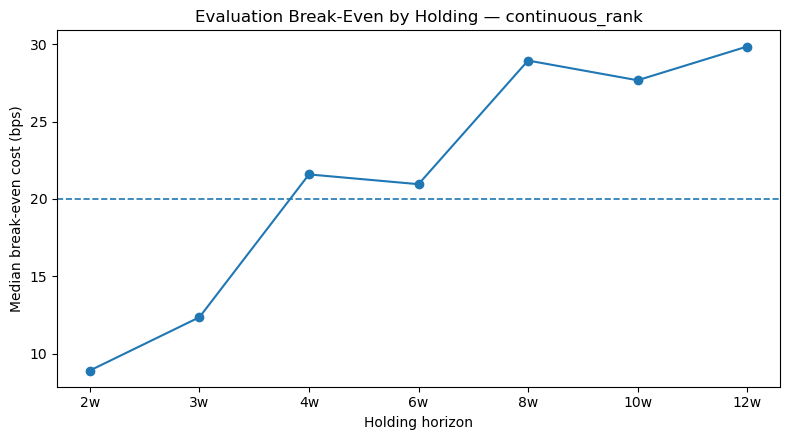

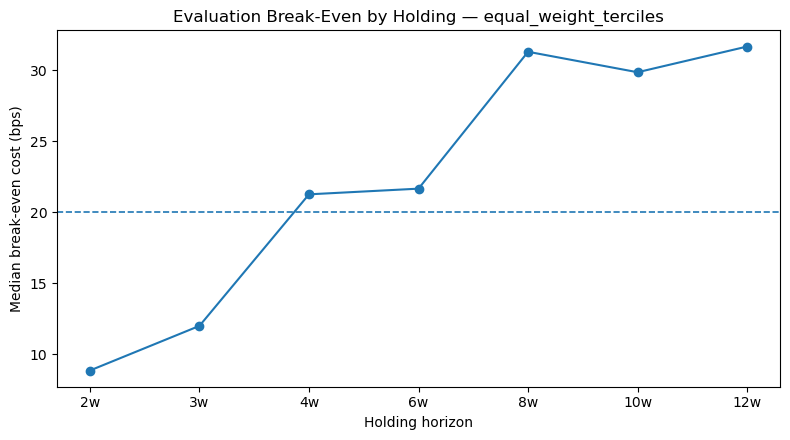

In [6]:
hold_order = ["2w", "3w", "4w", "6w", "8w", "10w", "12w"]

for mapping in ["continuous_rank", "equal_weight_terciles"]:
    plot_data = evaluation_hold.loc[
        evaluation_hold["portfolio_mapping"].eq(mapping)
    ].copy()
    plot_data["holding_horizon"] = pd.Categorical(
        plot_data["holding_horizon"],
        categories=hold_order,
        ordered=True,
    )
    plot_data = plot_data.sort_values("holding_horizon")

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(
        plot_data["holding_horizon"].astype(str),
        plot_data["median_break_even_bps"],
        marker="o",
    )
    ax.axhline(20.0, linestyle="--", linewidth=1.2)
    ax.set_title(f"Evaluation Break-Even by Holding — {mapping}")
    ax.set_xlabel("Holding horizon")
    ax.set_ylabel("Median break-even cost (bps)")
    fig.tight_layout()
    plt.show()

The extension shows that continuation economics improve materially with overlapping multi-week holdings. The economically central region moves well inside the tested grid, especially around **6–8 weeks**, rather than remaining pinned to the old 2-week boundary.

Gross Sharpe peaks earlier than break-even economics, revealing a genuine performance-versus-turnover tradeoff.

## 4. Longer formation and cadence map

Because longer formations were already part of the project's original declared horizon family, the continuation research next tests whether the multi-week architecture also has an interior formation optimum.

Locked grid:

- formation: 12h, 1d, 2d, 3d, 1w, 2w, 1m, 3m;
- holding: 4w, 6w, 8w, 10w, 12w;
- cadence: 4h, 8h, 12h, 24h, 48h;
- mappings: continuous rank and equal-weight terciles;
- windows: 2020–2022 development and 2023–2024 evaluation.

That is **200 structural cells** and **800 portfolio evaluations**. The 48h schedule uses a fixed UTC epoch anchor, so it is a true every-second-midnight schedule rather than every midnight.

In [7]:
long_extension_path = RESEARCH_DIR / "step11b4_longer_formation_candidate_results.csv"
if not long_extension_path.exists():
    raise FileNotFoundError(long_extension_path)

long_extension = pd.read_csv(long_extension_path)
assert len(long_extension) == 800
assert np.isfinite(long_extension["mean_price_ic"]).all()
assert np.isfinite(long_extension["break_even_cost_bps"]).all()
assert np.isfinite(long_extension["gross_sharpe_ann"]).all()

long_extension["final_expiry"] = pd.to_datetime(
    long_extension["final_expiry"], utc=True
)
assert long_extension["final_expiry"].max() <= FINAL_TEST_START

formation_summary = (
    long_extension
    .groupby(
        ["portfolio_mapping", "window", "formation_horizon"],
        observed=True,
    )
    .agg(
        cells=("break_even_cost_bps", "size"),
        median_break_even_bps=("break_even_cost_bps", "median"),
        median_gross_sharpe=("gross_sharpe_ann", "median"),
        median_net20_sharpe=("net20_sharpe_ann", "median"),
        median_price_ic=("mean_price_ic", "median"),
        cells_ge_20bps=("passes_20bps_cell_gate", "sum"),
        median_ann_turnover=("annualized_turnover", "median"),
    )
    .reset_index()
)
assert formation_summary["cells"].eq(25).all()

holding_summary = (
    long_extension
    .groupby(
        ["portfolio_mapping", "window", "holding_horizon"],
        observed=True,
    )
    .agg(
        cells=("break_even_cost_bps", "size"),
        median_break_even_bps=("break_even_cost_bps", "median"),
        median_gross_sharpe=("gross_sharpe_ann", "median"),
        median_price_ic=("mean_price_ic", "median"),
    )
    .reset_index()
)
assert holding_summary["cells"].eq(40).all()

cadence_summary = (
    long_extension
    .groupby(
        ["portfolio_mapping", "window", "decision_cadence"],
        observed=True,
    )
    .agg(
        cells=("break_even_cost_bps", "size"),
        median_break_even_bps=("break_even_cost_bps", "median"),
        median_gross_sharpe=("gross_sharpe_ann", "median"),
        median_price_ic=("mean_price_ic", "median"),
        median_ann_turnover=("annualized_turnover", "median"),
    )
    .reset_index()
)
assert cadence_summary["cells"].eq(40).all()

evaluation_formation = formation_summary.loc[
    formation_summary["window"].eq("evaluation")
].copy()
evaluation_holding = holding_summary.loc[
    holding_summary["window"].eq("evaluation")
].copy()
evaluation_cadence = cadence_summary.loc[
    cadence_summary["window"].eq("evaluation")
].copy()

print("Evaluation — formation summary:")
display(evaluation_formation.round(6))
print("\nEvaluation — holding summary:")
display(evaluation_holding.round(6))
print("\nEvaluation — cadence summary:")
display(evaluation_cadence.round(6))

# Key frozen region checks from the completed run.
expected_eval_formation = {
    ("continuous_rank", "12h"): (31.6, 1.19),
    ("continuous_rank", "1d"): (40.6, 1.35),
    ("continuous_rank", "2d"): (37.4, 1.07),
    ("continuous_rank", "3d"): (41.4, 1.00),
    ("continuous_rank", "1w"): (47.5, 0.72),
    ("continuous_rank", "2w"): (58.6, 0.63),
    ("equal_weight_terciles", "12h"): (33.1, 1.33),
    ("equal_weight_terciles", "1d"): (42.0, 1.48),
    ("equal_weight_terciles", "3d"): (42.2, 1.10),
    ("equal_weight_terciles", "2w"): (49.9, 0.69),
}
eval_form_idx = evaluation_formation.set_index(
    ["portfolio_mapping", "formation_horizon"]
)
for key, (expected_be, expected_sharpe) in expected_eval_formation.items():
    actual_be = float(eval_form_idx.loc[key, "median_break_even_bps"])
    actual_sharpe = float(eval_form_idx.loc[key, "median_gross_sharpe"])
    assert np.isclose(actual_be, expected_be, atol=0.06)
    assert np.isclose(actual_sharpe, expected_sharpe, atol=0.01)

# 3m formation must fail decisively in evaluation for both mappings.
for mapping in ["continuous_rank", "equal_weight_terciles"]:
    row = eval_form_idx.loc[(mapping, "3m")]
    assert float(row["median_break_even_bps"]) < 0
    assert float(row["median_gross_sharpe"]) < 0

print("\n11B.4 formation/holding/cadence integrity: PASS")
print("Latest final expiry:", long_extension["final_expiry"].max())
print("2025+ touched:", False)

Evaluation — formation summary:


,portfolio_mapping,window,formation_horizon,cells,median_break_even_bps,median_gross_sharpe,median_net20_sharpe,median_price_ic,cells_ge_20bps,median_ann_turnover
8,continuous_rank,evaluation,12h,25,31.635922,1.193329,0.473352,0.029406,21,81.319111
9,continuous_rank,evaluation,1d,25,40.590793,1.348602,0.658326,0.037424,25,67.058061
10,continuous_rank,evaluation,1m,25,45.731963,0.382867,0.215384,0.041851,25,16.955107
11,continuous_rank,evaluation,1w,25,47.533864,0.717062,0.399291,0.041078,25,30.257657
12,continuous_rank,evaluation,2d,25,37.410476,1.071716,0.427280,0.033972,25,52.497818
13,continuous_rank,evaluation,2w,25,58.629282,0.629730,0.422235,0.048758,25,22.213413
14,continuous_rank,evaluation,3d,25,41.432119,0.998009,0.528296,0.035142,25,43.590280
15,continuous_rank,evaluation,3m,25,-10.726417,-0.055779,-0.151927,-0.042845,0,10.876554
24,equal_weight_terciles,evaluation,12h,25,33.063446,1.330393,0.520619,0.029406,23,80.482601
25,equal_weight_terciles,evaluation,1d,25,41.987301,1.478137,0.670951,0.037424,25,64.286233



Evaluation — holding summary:


,portfolio_mapping,window,holding_horizon,cells,median_break_even_bps,median_gross_sharpe,median_price_ic
5,continuous_rank,evaluation,10w,40,38.027003,0.630025,0.034749
6,continuous_rank,evaluation,12w,40,34.655270,0.560754,0.036587
7,continuous_rank,evaluation,4w,40,39.119798,0.913464,0.027729
8,continuous_rank,evaluation,6w,40,44.043163,0.970888,0.036935
9,continuous_rank,evaluation,8w,40,52.816175,0.875164,0.040908
15,equal_weight_terciles,evaluation,10w,40,38.123679,0.599220,0.034749
16,equal_weight_terciles,evaluation,12w,40,34.962465,0.509950,0.036587
17,equal_weight_terciles,evaluation,4w,40,32.549242,0.906641,0.027729
18,equal_weight_terciles,evaluation,6w,40,45.094483,0.942384,0.036935
19,equal_weight_terciles,evaluation,8w,40,48.225191,0.865576,0.040908



Evaluation — cadence summary:


,portfolio_mapping,window,decision_cadence,cells,median_break_even_bps,median_gross_sharpe,median_price_ic,median_ann_turnover
5,continuous_rank,evaluation,12h,40,41.332535,0.857194,0.036156,38.121322
6,continuous_rank,evaluation,24h,40,38.346635,0.814477,0.035007,37.530043
7,continuous_rank,evaluation,48h,40,53.893302,0.829723,0.038025,35.678534
8,continuous_rank,evaluation,4h,40,38.266621,0.830948,0.036448,38.859726
9,continuous_rank,evaluation,8h,40,39.292319,0.798586,0.036641,38.530319
15,equal_weight_terciles,evaluation,12h,40,39.372715,0.827250,0.036156,38.716718
16,equal_weight_terciles,evaluation,24h,40,40.474399,0.786692,0.035007,38.070435
17,equal_weight_terciles,evaluation,48h,40,48.175869,0.715092,0.038025,36.118672
18,equal_weight_terciles,evaluation,4h,40,34.308977,0.788725,0.036448,39.703601
19,equal_weight_terciles,evaluation,8h,40,36.658620,0.759634,0.036641,39.148634



11B.4 formation/holding/cadence integrity: PASS
Latest final expiry: 2025-01-01 00:00:00+00:00
2025+ touched: False


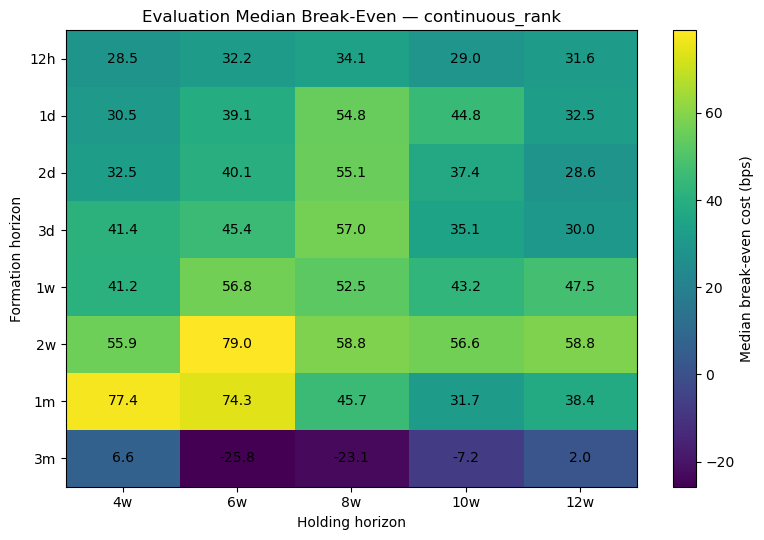

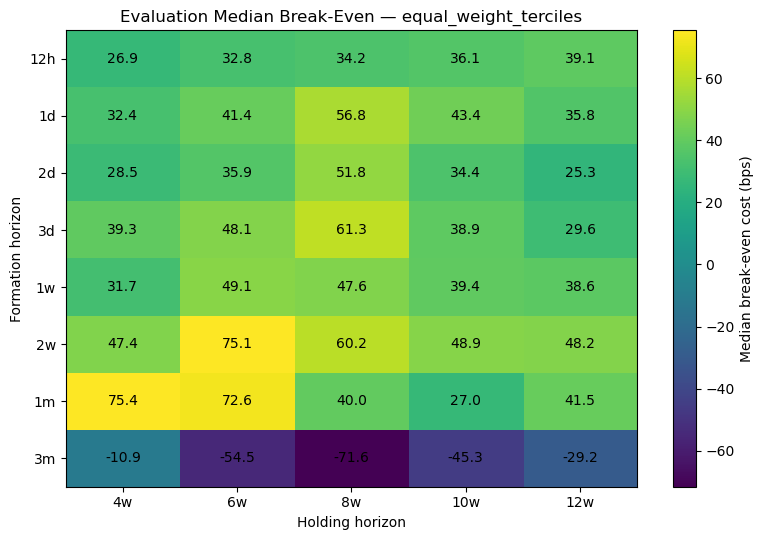

In [8]:
formation_order = ["12h", "1d", "2d", "3d", "1w", "2w", "1m", "3m"]
holding_order = ["4w", "6w", "8w", "10w", "12w"]

for mapping in ["continuous_rank", "equal_weight_terciles"]:
    sub = long_extension.loc[
        long_extension["window"].eq("evaluation")
        & long_extension["portfolio_mapping"].eq(mapping)
    ].copy()

    heat = (
        sub.groupby(
            ["formation_horizon", "holding_horizon"],
            observed=True,
        )["break_even_cost_bps"]
        .median()
        .unstack("holding_horizon")
        .reindex(index=formation_order, columns=holding_order)
    )

    fig, ax = plt.subplots(figsize=(8, 5.5))
    image = ax.imshow(heat.to_numpy(), aspect="auto")
    ax.set_xticks(range(len(holding_order)), holding_order)
    ax.set_yticks(range(len(formation_order)), formation_order)
    ax.set_xlabel("Holding horizon")
    ax.set_ylabel("Formation horizon")
    ax.set_title(f"Evaluation Median Break-Even — {mapping}")

    for r in range(heat.shape[0]):
        for c in range(heat.shape[1]):
            ax.text(c, r, f"{heat.iloc[r, c]:.1f}", ha="center", va="center")

    fig.colorbar(image, ax=ax, label="Median break-even cost (bps)")
    fig.tight_layout()
    plt.show()

### Surface interpretation

The completed pre-2025 extension reveals a **broad interior continuation region**, not a single isolated optimum:

- formation is broadly viable from roughly **1 day through 2 weeks**;
- **6–8 week** holdings form the central economic region;
- 24h–48h implementation can materially reduce turnover, although slower cadence does not always maximize Sharpe;
- 1m formation is unstable across windows;
- **3m formation fails sharply**, showing that the effect is not simply “longer lookback is better.”

The extension therefore supports a distinct multi-week continuation architecture, not a rescue of the failed static 3d → 1w Cycle-A momentum trade.

## 5. Freeze three pre-2025 continuation archetypes

Rather than choose one arbitrary objective from a broad viable surface, the research freezes three exact representatives of different implementation philosophies:

- **ECON:** economic resilience / cost headroom;
- **BAL:** balanced robustness;
- **SHARP:** higher risk-adjusted performance.

These definitions are frozen **before any 2025+ performance is viewed**. The final holdout will evaluate all three independently; it will not select a winner after the fact.

In [9]:
FROZEN_FINALISTS = pd.DataFrame([
    {
        "id": "ECON",
        "philosophy": "Economic resilience",
        "mapping": "continuous_rank",
        "formation": "2w",
        "holding": "6w",
        "cadence": "24h",
        "development_be_bps": 81.031675,
        "evaluation_be_bps": 78.969452,
        "development_gross_sharpe": 0.787083,
        "evaluation_gross_sharpe": 0.915241,
        "development_net20_sharpe": 0.592814,
        "evaluation_net20_sharpe": 0.683478,
        "development_ic": 0.034947,
        "evaluation_ic": 0.053920,
    },
    {
        "id": "BAL",
        "philosophy": "Balanced",
        "mapping": "equal_weight_terciles",
        "formation": "3d",
        "holding": "8w",
        "cadence": "48h",
        "development_be_bps": 102.321795,
        "evaluation_be_bps": 72.991227,
        "development_gross_sharpe": 1.450295,
        "evaluation_gross_sharpe": 1.416566,
        "development_net20_sharpe": 1.166567,
        "evaluation_net20_sharpe": 1.028728,
        "development_ic": 0.043771,
        "evaluation_ic": 0.043501,
    },
    {
        "id": "SHARP",
        "philosophy": "Higher Sharpe",
        "mapping": "equal_weight_terciles",
        "formation": "1d",
        "holding": "8w",
        "cadence": "8h",
        "development_be_bps": 73.074611,
        "evaluation_be_bps": 60.912835,
        "development_gross_sharpe": 2.129700,
        "evaluation_gross_sharpe": 1.939187,
        "development_net20_sharpe": 1.546595,
        "evaluation_net20_sharpe": 1.302612,
        "development_ic": 0.034247,
        "evaluation_ic": 0.042936,
    },
])

# Prove that each frozen archetype is an exact row of the completed pre-2025 grid.
metric_map = {
    "development_be_bps": "break_even_cost_bps",
    "evaluation_be_bps": "break_even_cost_bps",
    "development_gross_sharpe": "gross_sharpe_ann",
    "evaluation_gross_sharpe": "gross_sharpe_ann",
    "development_net20_sharpe": "net20_sharpe_ann",
    "evaluation_net20_sharpe": "net20_sharpe_ann",
    "development_ic": "mean_price_ic",
    "evaluation_ic": "mean_price_ic",
}

for _, finalist in FROZEN_FINALISTS.iterrows():
    base = long_extension.loc[
        long_extension["portfolio_mapping"].eq(finalist["mapping"])
        & long_extension["formation_horizon"].eq(finalist["formation"])
        & long_extension["holding_horizon"].eq(finalist["holding"])
        & long_extension["decision_cadence"].eq(finalist["cadence"])
    ].copy()

    assert set(base["window"]) == {"development", "evaluation"}

    for public_metric, source_metric in metric_map.items():
        window = "development" if public_metric.startswith("development") else "evaluation"
        actual = float(base.loc[base["window"].eq(window), source_metric].iloc[0])
        expected = float(finalist[public_metric])
        assert np.isclose(actual, expected, atol=5e-6), (
            finalist["id"], public_metric, actual, expected
        )

display(FROZEN_FINALISTS.round(6))

print("Exact pre-2025 finalist-row reproduction: PASS")
print("Finalist count:", len(FROZEN_FINALISTS))
print("2025+ performance viewed in this notebook:", False)

,id,philosophy,mapping,formation,holding,cadence,development_be_bps,evaluation_be_bps,development_gross_sharpe,evaluation_gross_sharpe,development_net20_sharpe,evaluation_net20_sharpe,development_ic,evaluation_ic
0,ECON,Economic resilience,continuous_rank,2w,6w,24h,81.031675,78.969452,0.787083,0.915241,0.592814,0.683478,0.034947,0.053920
1,BAL,Balanced,equal_weight_terciles,3d,8w,48h,102.321795,72.991227,1.450295,1.416566,1.166567,1.028728,0.043771,0.043501
2,SHARP,Higher Sharpe,equal_weight_terciles,1d,8w,8h,73.074611,60.912835,2.129700,1.939187,1.546595,1.302612,0.034247,0.042936


Exact pre-2025 finalist-row reproduction: PASS
Finalist count: 3
2025+ performance viewed in this notebook: False


## 6. Pre-holdout conclusion

The original strategy failed validation and remains a negative result.

The pre-2025 redesign supports a **different multi-week cross-sectional continuation architecture**:

- very-short reversal remains statistically persistent but economically unusable at the primary 20-bps cost assumption;
- continuation becomes economically viable only after extending into overlapping multi-week holdings;
- the viable continuation region is broad across neighboring formation, holding, and cadence choices;
- performance decays by multi-month formation horizons;
- no market-state filter, reversal/continuation combination, or 2025+ rescue is used.

At this point the research is frozen to **ECON, BAL, and SHARP**.

The next notebook performs the untouched final holdout. No parameter in the table above may change after that holdout is opened.